In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('/content/nepal_293_cities_weather_2020_2025.csv')


In [4]:
print(df.head())

         Date                      City      CityType District  Latitude  \
0  2020-07-19  Sanphebagar Municipality  Municipality   Achham     29.12   
1  2020-07-20  Sanphebagar Municipality  Municipality   Achham     29.12   
2  2020-07-21  Sanphebagar Municipality  Municipality   Achham     29.12   
3  2020-07-22  Sanphebagar Municipality  Municipality   Achham     29.12   
4  2020-07-23  Sanphebagar Municipality  Municipality   Achham     29.12   

   Longitude  Precip  Pressure  Humidity_2m  RH_2m  ...  MaxTemp_2m  \
0       81.3     0.0     86.93        19.69  93.48  ...       25.70   
1       81.3     0.0     86.79        19.68  90.34  ...       27.68   
2       81.3     0.0     87.09        18.52  90.08  ...       26.79   
3       81.3     0.0     87.10        17.31  83.29  ...       27.51   
4       81.3     0.0     87.17        17.35  88.13  ...       26.24   

   MinTemp_2m  EarthSkinTemp  WindSpeed_10m  MaxWindSpeed_10m  \
0       21.35          23.69           2.31        

In [5]:
summary = df.describe()
print(summary)

           Latitude     Longitude   Precip      Pressure   Humidity_2m  \
count  40940.000000  40940.000000  40940.0  40940.000000  40940.000000   
mean      28.401180     82.627233      0.0     86.248176     10.318186   
std        0.969758      1.751205      0.0     10.199732      5.710813   
min       27.020000     80.430000      0.0     69.300000      1.380000   
25%       27.020000     81.300000      0.0     75.590000      5.310000   
50%       28.270000     81.620000      0.0     87.450000      8.980000   
75%       29.510000     85.050000      0.0     97.670000     14.810000   
max       29.720000     85.050000      0.0     99.710000     24.120000   

              RH_2m       Temp_2m  WetBulbTemp_2m    MaxTemp_2m    MinTemp_2m  \
count  40940.000000  40940.000000    40940.000000  40939.000000  40939.000000   
mean      63.656180     18.226360       13.946212     23.826111     13.736284   
std       21.515589      8.214179        8.458522      8.101577      8.308317   
min      

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40940 entries, 0 to 40939
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Date              40940 non-null  object 
 1   City              40940 non-null  object 
 2   CityType          40940 non-null  object 
 3   District          40940 non-null  object 
 4   Latitude          40940 non-null  float64
 5   Longitude         40940 non-null  float64
 6   Precip            40940 non-null  float64
 7   Pressure          40940 non-null  float64
 8   Humidity_2m       40940 non-null  float64
 9   RH_2m             40940 non-null  float64
 10  Temp_2m           40940 non-null  float64
 11  WetBulbTemp_2m    40940 non-null  float64
 12  MaxTemp_2m        40939 non-null  float64
 13  MinTemp_2m        40939 non-null  float64
 14  EarthSkinTemp     40939 non-null  float64
 15  WindSpeed_10m     40939 non-null  float64
 16  MaxWindSpeed_10m  40939 non-null  float6

In [7]:
print(df.isnull().sum())

Date                0
City                0
CityType            0
District            0
Latitude            0
Longitude           0
Precip              0
Pressure            0
Humidity_2m         0
RH_2m               0
Temp_2m             0
WetBulbTemp_2m      0
MaxTemp_2m          1
MinTemp_2m          1
EarthSkinTemp       1
WindSpeed_10m       1
MaxWindSpeed_10m    1
MinWindSpeed_10m    1
WindSpeed_50m       1
MaxWindSpeed_50m    1
MinWindSpeed_50m    1
Temp_2m_tomorrow    1
dtype: int64


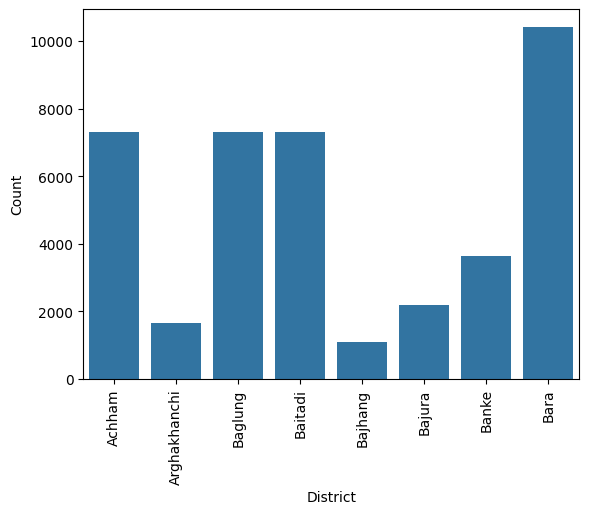

In [8]:
sns.countplot(x=df['District'])
plt.xticks(rotation=90)
plt.xlabel('District')
plt.ylabel('Count')
plt.show()

In [9]:
grouped_df = df.groupby('District').size().reset_index(name='Count')

In [10]:
result = grouped_df.sort_values(by='Count', ascending=False).head(10)
print(result)

       District  Count
7          Bara  10426
0        Achham   7304
3       Baitadi   7304
2       Baglung   7304
6         Banke   3652
5        Bajura   2200
1  Arghakhanchi   1650
4       Bajhang   1100


Text(0, 0.5, 'Count')

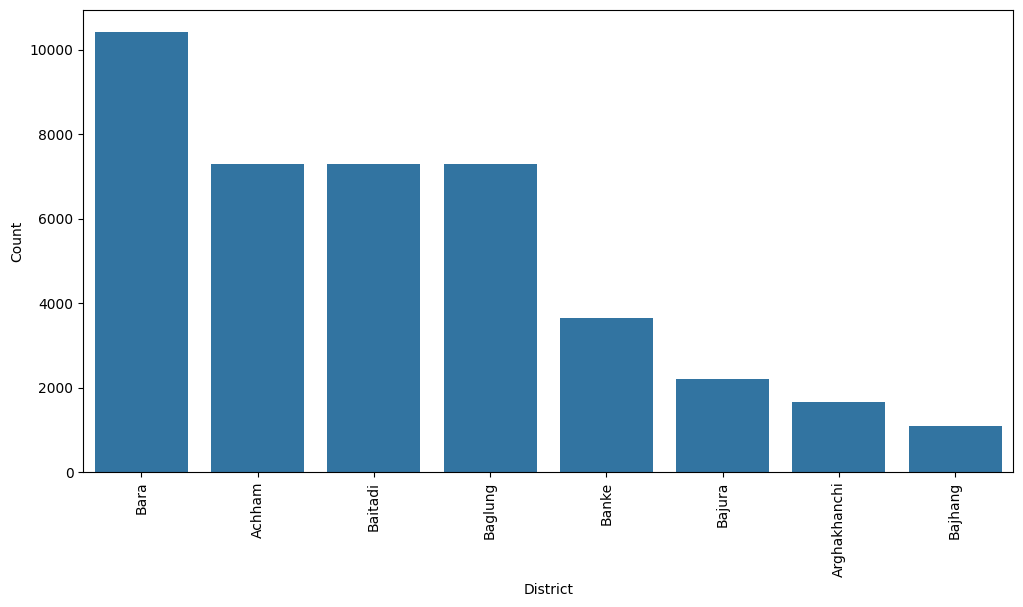

In [11]:
plt.figure(figsize=(12, 6))
sns.barplot(x='District', y='Count', data=result)
plt.xticks(rotation=90)
plt.xlabel('District')
plt.ylabel('Count')

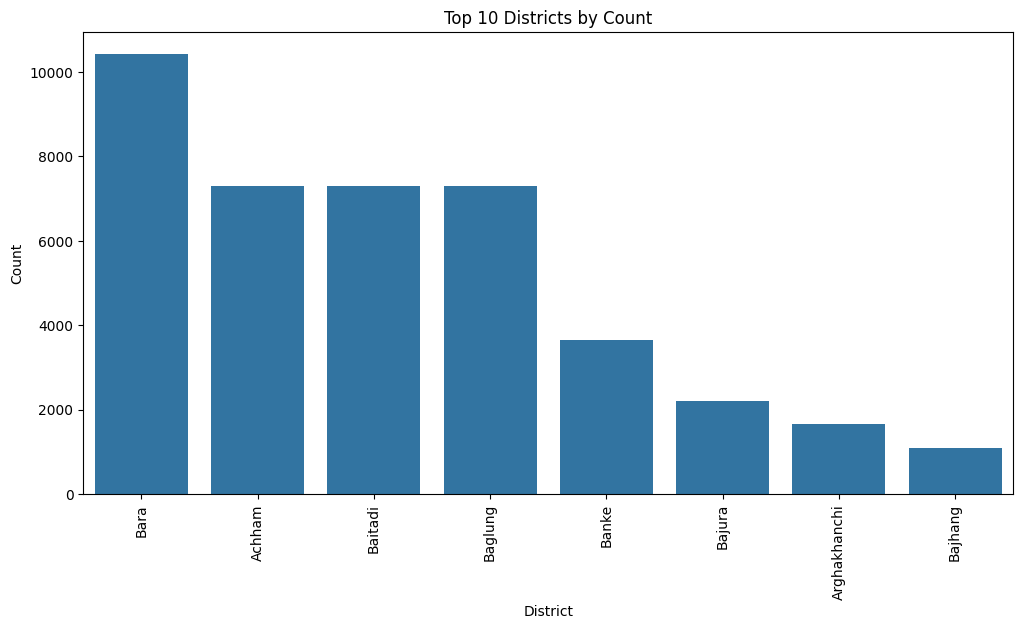

In [12]:
plt.figure(figsize=(12, 6))
sns.barplot(x='District', y='Count', data=result)
plt.xticks(rotation=90)
plt.xlabel('District')
plt.ylabel('Count')
plt.title('Top 10 Districts by Count')
plt.show()

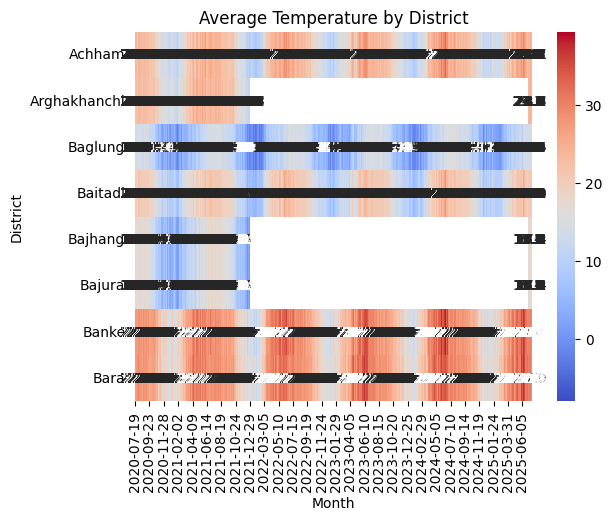

In [15]:
pivot_table = df.pivot_table(index='District', columns='Date', values='Temp_2m', aggfunc='mean')
sns.heatmap(pivot_table, cmap='coolwarm', annot=True, fmt=".1f")
plt.title('Average Temperature by District')
plt.xlabel('Month')
plt.ylabel('District')
plt.show()